**Anemia prediction using machine learning**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report
from yellowbrick.classifier import ConfusionMatrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

# Loading the dataset


In [ ]:
df=pd.read_csv("/content/anemiaDataset.csv")

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Number        500 non-null    int64  
 1   Gender        500 non-null    object 
 2   %Red Pixel    500 non-null    float64
 3   %Green pixel  500 non-null    float64
 4   %Blue pixel   500 non-null    float64
 5   Hb            500 non-null    float64
 6   Anaemic       500 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 27.5+ KB


In [ ]:
df=df.drop('Number',axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Gender        500 non-null    object 
 1   %Red Pixel    500 non-null    float64
 2   %Green pixel  500 non-null    float64
 3   %Blue pixel   500 non-null    float64
 4   Hb            500 non-null    float64
 5   Anaemic       500 non-null    object 
dtypes: float64(4), object(2)
memory usage: 23.6+ KB


In [ ]:
df['Gender'].unique()

array(['M', 'F', 'M ', 'F '], dtype=object)

In [ ]:
df['Gender']=df['Gender'].replace('M ','M')
df['Gender']=df['Gender'].replace('F ','F')

In [ ]:
df['Gender'].unique()

array(['M', 'F'], dtype=object)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
enc = OneHotEncoder(sparse_output=False, drop='first')
#drop='first', it only generates one column (e.g., Gender_Female) instead of Gender_female and Gender_male as 2 separate columns, which will take the value 1 when the original value was "Female" and 0 otherwise.

# Fit and transform the 'Gender' column
encoded_Gender = enc.fit_transform(df[['Gender']])

# Convert the one-hot encoded array to a DataFrame with the new columns
encoded_Gender_df = pd.DataFrame(encoded_Gender, columns=enc.get_feature_names_out(['Gender']))

# Combine the original DataFrame with the new one-hot encoded columns, replacing the 'Gender' column
df = df.drop('Gender', axis=1).join(encoded_Gender_df)

# Show the updated DataFrame
df.head()

,%Red Pixel,%Green pixel,%Blue pixel,Hb,Anaemic,Gender_M
0,43.97,28.36,26.41,5.15,Yes,1.0
1,44.01,29.22,27.33,7.97,Yes,0.0
2,47.77,27.73,24.61,9.14,Yes,0.0
3,45.96,30.69,25.19,4.00,Yes,0.0
4,46.91,31.26,22.21,9.90,Yes,1.0


In [ ]:
df.describe()

,%Red Pixel,%Green pixel,%Blue pixel,Hb,Gender_M
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,44.913580,29.349720,25.570440,10.893100,0.458000
std,2.950017,1.844623,2.215913,3.040943,0.498732
min,36.800000,24.150000,17.950000,4.000000,0.000000
25%,43.000000,28.130000,24.550000,8.920000,0.000000
50%,44.555000,29.480000,25.935000,9.950000,0.000000
75%,46.465000,30.692500,27.002500,13.330000,1.000000
max,56.850000,33.600000,31.300000,18.550000,1.000000


In [ ]:
df.isnull().sum()

,0
%Red Pixel,0
%Green pixel,0
%Blue pixel,0
Hb,0
Anaemic,0
Gender_M,0


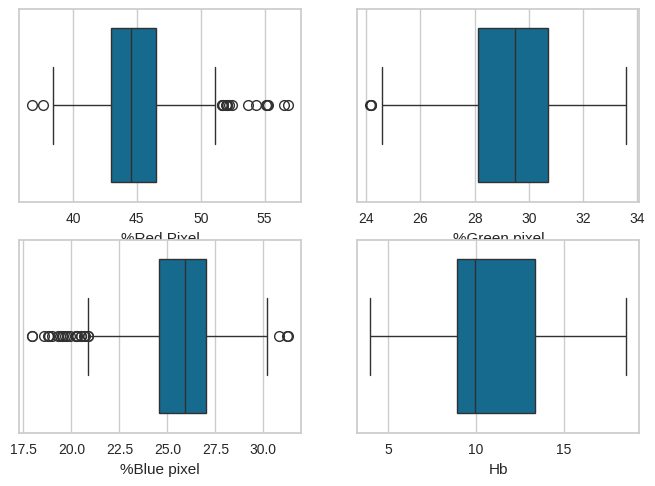

In [ ]:
plt.subplot(2,2,1)
sns.boxplot(df,x="%Red Pixel")
plt.subplot(2,2,2)
sns.boxplot(df,x="%Green pixel")
plt.subplot(2,2,3)
sns.boxplot(df,x="%Blue pixel")
plt.subplot(2,2,4)
sns.boxplot(df,x="Hb")
plt.show()

In [ ]:
df['Anaemic'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df['Anaemic']=df['Anaemic'].map({'Yes':1,'No':0})
df.head()

,%Red Pixel,%Green pixel,%Blue pixel,Hb,Anaemic,Gender_M
0,43.97,28.36,26.41,5.15,1,1.0
1,44.01,29.22,27.33,7.97,1,0.0
2,47.77,27.73,24.61,9.14,1,0.0
3,45.96,30.69,25.19,4.00,1,0.0
4,46.91,31.26,22.21,9.90,1,1.0


In [ ]:
x=df.drop('Anaemic',axis=1)
y=df['Anaemic']


# Feature Scaling

In [ ]:
x= StandardScaler().fit(x).transform(x)
x

array([[-0.32017614, -0.53708046,  0.37925713, -1.89048333,  1.08784471],
       [-0.30660331, -0.07039373,  0.79485167, -0.96221062, -0.91924885],
       [ 0.96924216, -0.87895563, -0.43386263, -0.5770762 , -0.91924885],
       ...,
       [-0.89702117,  1.20485492,  0.812921  ,  0.26231933, -0.91924885],
       [-0.57466659,  0.11953692,  0.39732645,  0.86800082, -0.91924885],
       [ 0.44668843, -1.01462038,  0.32504914,  0.91079353, -0.91924885]])

In [ ]:
y

,Anaemic
0,1
1,1
2,1
3,1
4,1
...,...
495,0
496,0
497,0
498,0


# Data Splitting

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.4)
print ('Train set:', x_train.shape, y_train.shape)
print ('Test set:', x_test.shape,  y_test.shape)

Train set: (300, 5) (300,)
Test set: (200, 5) (200,)


# KNN Classifier

In [ ]:
knn=KNeighborsClassifier(n_neighbors=10)
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=10)

In [ ]:
y_predict_knn = knn.predict(x_test)

Accuracy

In [ ]:
accuracy_knn=knn.score(x_test,y_test)
print(accuracy_score(y_test,y_predict_knn))
print("KNN model accuracy(in %):{:.2f}%".format(accuracy_knn*100))

0.955
KNN model accuracy(in %):95.50%


Classification Report

In [ ]:
print(classification_report(y_test, y_predict_knn))


              precision    recall  f1-score   support

           0       0.98      0.92      0.95        92
           1       0.94      0.98      0.96       108

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.95       200
weighted avg       0.96      0.95      0.95       200



In [ ]:
classes = ['0', '1']

Confusion Matrix

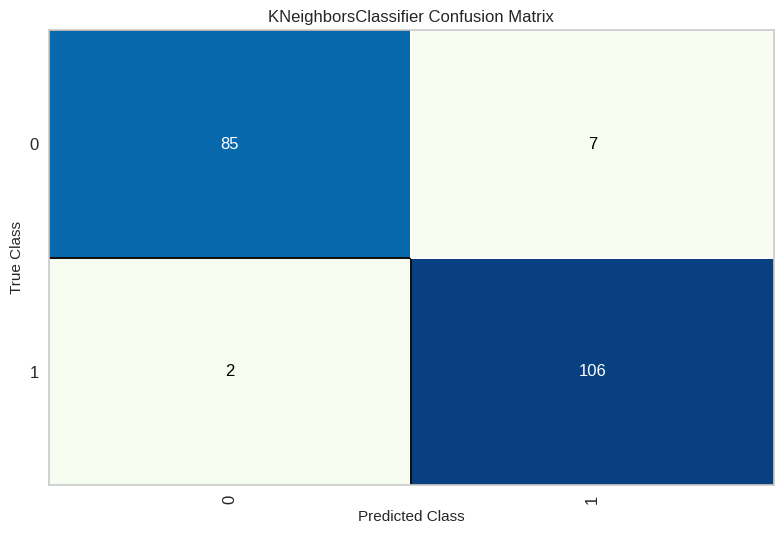

<Axes: title={'center': 'KNeighborsClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [ ]:


knn_cm = ConfusionMatrix(knn, classes=classes, cmap='GnBu')

knn_cm.fit(x_train, y_train)
knn_cm.score(x_test, y_test)
knn_cm.show()

# Decision Tree

In [ ]:
dt=DecisionTreeClassifier(criterion="entropy",random_state=0)
dt.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

Accuracy

In [ ]:
y_pred_dt=dt.predict(x_test)
accuracy_tree=accuracy_score(y_test,y_pred_dt)
print("Decision Tree model accuracy(in %):{:.2f}%".format(accuracy_tree*100))

Decision Tree model accuracy(in %):100.00%


Classification Report

In [ ]:
print(classification_report(y_test, y_pred_dt))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        92
           1       1.00      1.00      1.00       108

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



Confusion Matrix

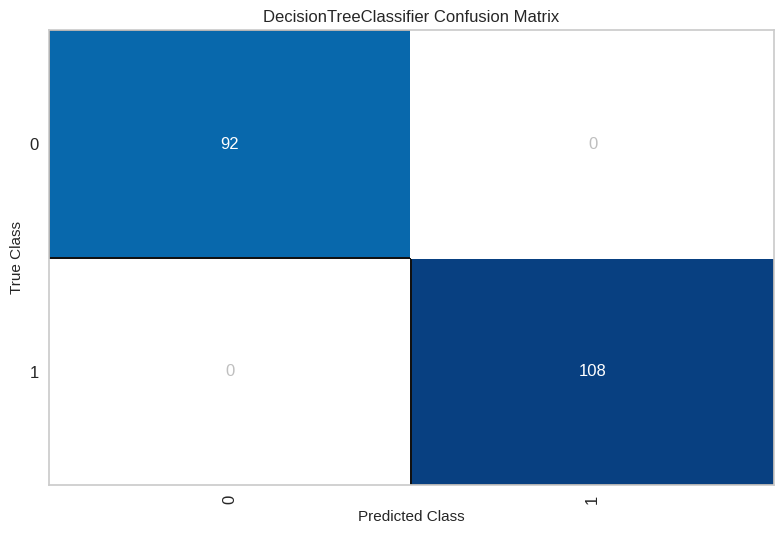

<Axes: title={'center': 'DecisionTreeClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [ ]:
dt_cm = ConfusionMatrix(dt, classes=classes, cmap='GnBu')

dt_cm.fit(x_train, y_train)
dt_cm.score(x_test, y_test)
dt_cm.show()

# Random Forest Classifier

In [ ]:
# rf=RandomForestClassifier(n_estimators=20,criterion='entropy')
# rf.fit(x_train,y_train)

In [ ]:
from sklearn.model_selection import cross_val_score

# Random Forest model (you can apply this to other models similarly)
rf = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)

# Perform 5-fold cross-validation
# `cv=5` means it splits the data into 5 parts, trains on 4, and tests on 1, rotating the test set each time.
cv_scores_rf = cross_val_score(rf, x, y, cv=5)

# Print the cross-validation scores for each fold
print("Cross-Validation Scores for Random Forest:", cv_scores_rf)

# Calculate and print the mean and standard deviation of the scores
print("Average CV Score: {:.2f}%".format(cv_scores_rf.mean() * 100))
print("Standard Deviation of CV Score: {:.2f}%".format(cv_scores_rf.std() * 100))


Cross-Validation Scores for Random Forest: [1.   0.98 1.   1.   1.  ]
Average CV Score: 99.60%
Standard Deviation of CV Score: 0.80%


In [ ]:
rf.fit(x_train,y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

Accuracy

In [ ]:
y_pred_rf=rf.predict(x_test)
accuracy_forest=accuracy_score(y_test,y_pred_rf)
print("Random Forest model accuracy(in %):{:.2f}%".format(accuracy_forest*100))

Random Forest model accuracy(in %):99.50%


Classification Report

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99        92
           1       0.99      1.00      1.00       108

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



Confusion Matrix

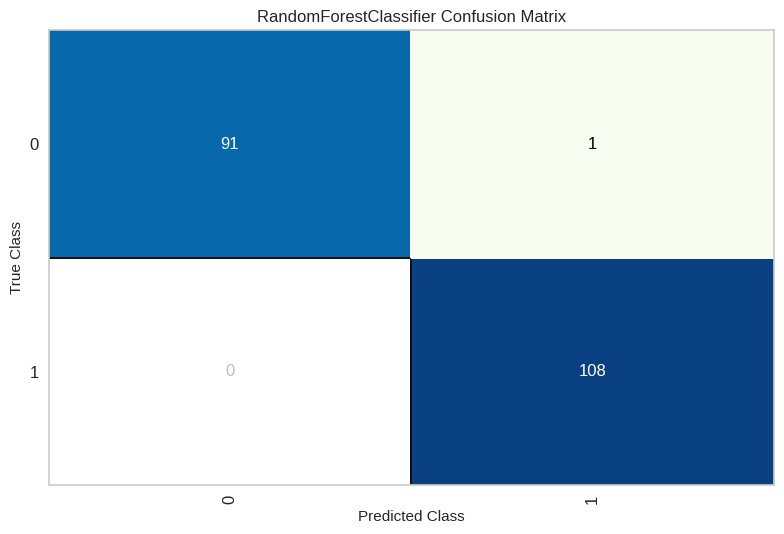

<Axes: title={'center': 'RandomForestClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [ ]:
rf_cm = ConfusionMatrix(rf, classes=classes, cmap='GnBu')

rf_cm.fit(x_train, y_train)
rf_cm.score(x_test, y_test)
rf_cm.show()

# Logistic Regression

In [ ]:
LR = LogisticRegression()
LR.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred_lr = LR.predict(x_test)

Accuracy

In [ ]:
accuracy_logistic=accuracy_score(y_test,y_pred_lr)
print("Logistic Regression model accuracy(in %):{:.4f}%".format(accuracy_logistic*100))

Logistic Regression model accuracy(in %):98.0000%


Classification Report

In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        92
           1       0.97      0.99      0.98       108

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



Confusion Matrix

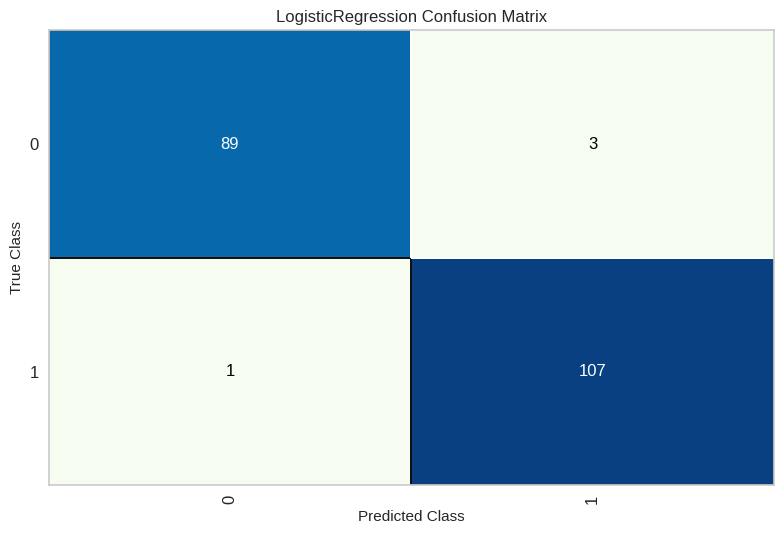

<Axes: title={'center': 'LogisticRegression Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [ ]:
lr_cm = ConfusionMatrix(LR, classes=classes, cmap='GnBu')

lr_cm.fit(x_train, y_train)
lr_cm.score(x_test, y_test)
lr_cm.show()

# SVM Classifier

In [ ]:
svc=SVC()
svc.fit(x_train,y_train)

SVC()

Accuracy

In [ ]:
y_pred_svc=svc.predict(x_test)
accuracy_svc=accuracy_score(y_test,y_pred_svc)
print("SVM model accuracy(in %):{:.4f}%".format(accuracy_svc*100))

SVM model accuracy(in %):97.0000%


Classification Report

In [ ]:
print(classification_report(y_test, y_pred_svc))

              precision    recall  f1-score   support

           0       1.00      0.93      0.97        92
           1       0.95      1.00      0.97       108

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200



Confusion Matrix

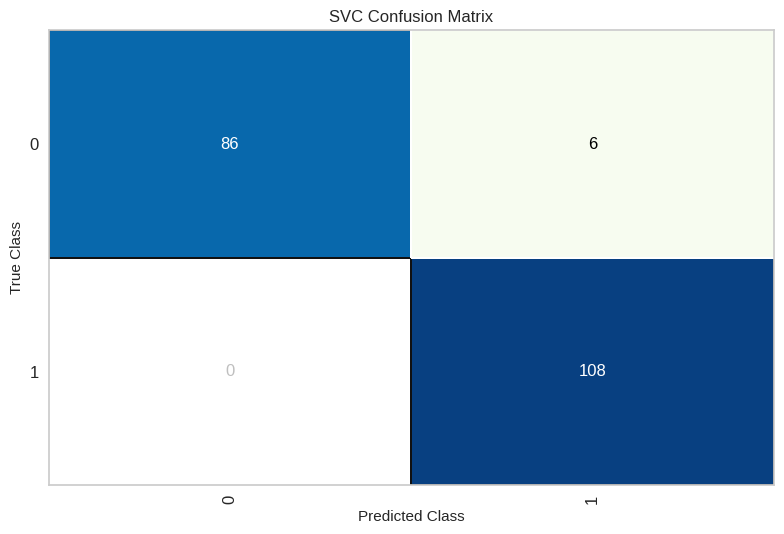

<Axes: title={'center': 'SVC Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [ ]:
svc_cm = ConfusionMatrix(svc, classes=classes, cmap='GnBu')

svc_cm.fit(x_train, y_train)
svc_cm.score(x_test, y_test)
svc_cm.show()

# Comparison of Classifiers

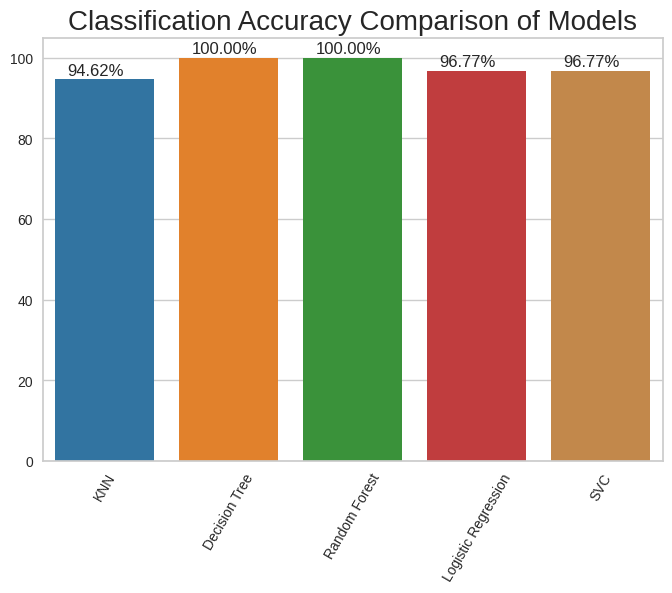

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Data
models = ['KNN', 'Decision Tree', 'Random Forest', 'Logistic Regression', 'SVC']
scores = [94.62,100.00,100.00,96.77,96.77]

# Define custom colors for each bar
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#d68837']  # Example colors

# Plot
ax = sns.barplot(x=models, y=scores, palette=colors)
ax.set_title('Classification Accuracy Comparison of Models', fontsize=20)

# Rotate x-axis labels
for item in ax.get_xticklabels():
    item.set_rotation(60)

# Annotate bars with their values
for p in ax.patches:
    ax.annotate('{:.2f}%'.format(p.get_height()), (p.get_x() + 0.1, p.get_height() + 1))

plt.show()


# Prediction using Random Forest Classifier

In [ ]:
df

,%Red Pixel,%Green pixel,%Blue pixel,Hb,Anaemic,Gender_M
0,43.97,28.36,26.41,5.15,1,1.0
1,44.01,29.22,27.33,7.97,1,0.0
2,47.77,27.73,24.61,9.14,1,0.0
3,45.96,30.69,25.19,4.00,1,0.0
4,46.91,31.26,22.21,9.90,1,1.0
...,...,...,...,...,...,...
495,44.87,27.52,26.57,14.19,0,0.0
496,44.85,28.20,24.44,11.94,0,0.0
497,42.27,31.57,27.37,11.69,0,0.0
498,43.22,29.57,26.45,13.53,0,0.0


In [2]:
import pandas as pd

# Load the dataset
file_path = "anemiaDataset.csv"
df = pd.read_csv(file_path)

def check_and_predict():
    # Get user input
    gender = input("Enter Gender (M/F): ")
    age = int(input("Enter Age: "))
    blood_group = input("Enter Blood Group (e.g., A+, O-, etc.): ")

    red_pixel = float(input("Enter % Red Pixel: "))
    green_pixel = float(input("Enter % Green Pixel: "))
    blue_pixel = float(input("Enter % Blue Pixel: "))
    hb = float(input("Enter Hb level: "))

    # Calculate pixel average
    pixel_average = (red_pixel + green_pixel + blue_pixel) / 3

    # Define the scoring system
    # Hb level impact (e.g., if Hb < 12, it increases anemia likelihood)
    if hb < 12:
        hb_score = 70  # 70% chance if Hb is low
    else:
        hb_score = 30  # 30% chance if Hb is normal

    # Pixel average impact (e.g., lower pixel average could suggest anemia-related features)
    if pixel_average < 50:
        pixel_score = 60  # 60% chance if pixel values are lower (may indicate anemia)
    else:
        pixel_score = 40  # 40% chance if pixel values are normal

    # Combine scores to get a weighted prediction
    # Adjust the weights based on the importance of Hb vs. pixel data (e.g., Hb might be more important)
    final_score = (hb_score * 0.6) + (pixel_score * 0.4)

    # Display results
    if final_score > 50:
        anaemic = "Yes. You are suffering from Anemia. Kindly consult a doctor soon."
    else:
        anaemic = "Good news! You are not suffering from Anemia."

    print(f"Gender: {gender}, Age: {age}, Blood Group: {blood_group}")
    print(f"Red Pixel: {red_pixel}%, Green Pixel: {green_pixel}%, Blue Pixel: {blue_pixel}%, Hb Level: {hb}")


    # Print the prediction
    print(f"Predicted Anaemic Status: {anaemic}")
    print(f"Likelihood of Anemia: {final_score:.2f}%")

# Run the prediction function
check_and_predict()

Enter Gender (M/F): f
Enter Age: 34
Enter Blood Group (e.g., A+, O-, etc.): o-
Enter % Red Pixel: 67
Enter % Green Pixel: 90
Enter % Blue Pixel: 56
Enter Hb level: 14
Gender: f, Age: 34, Blood Group: o-
Red Pixel: 67.0%, Green Pixel: 90.0%, Blue Pixel: 56.0%, Hb Level: 14.0
Predicted Anaemic Status: Good news! You are not suffering from Anemia.
Likelihood of Anemia: 34.00%
